In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('../data/synthetic_customer_churn_100k.csv')

In [5]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [6]:
df.shape

(100000, 9)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  str    
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  str    
 6   PaymentMethod   100000 non-null  str    
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 9.9 MB


In [8]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.140256
std,28867.657797,18.177862,20.789552,40.491961,2388.163672
min,1.000000,18.000000,1.000000,10.000000,-118.430000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500
max,100000.000000,80.000000,72.000000,150.000000,10831.460000


In [9]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Churn'].value_counts()

Churn
No     66856
Yes    33144
Name: count, dtype: int64

In [12]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     66.856
Yes    33.144
Name: proportion, dtype: float64

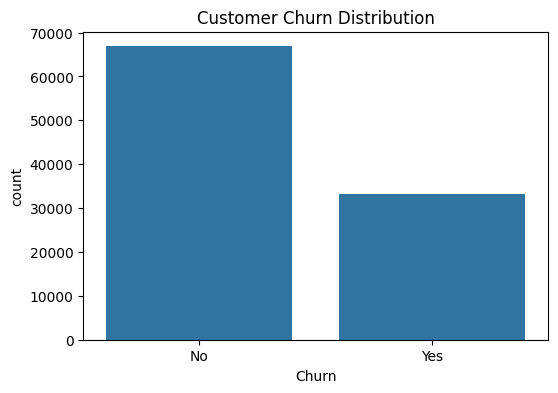

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Churn'
)

plt.title('Customer Churn Distribution')

plt.show()

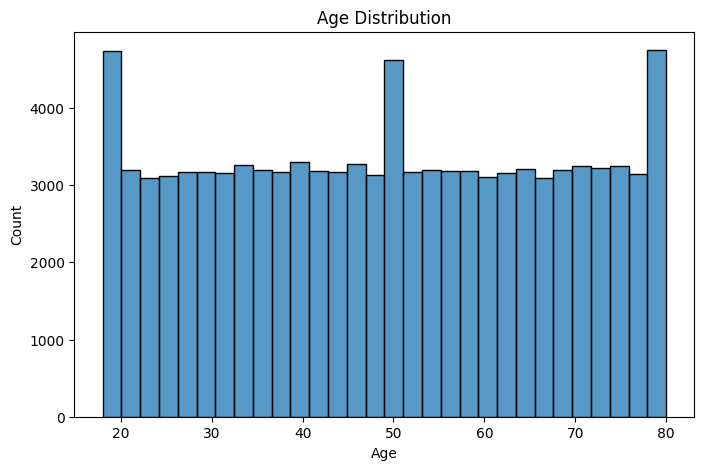

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30
)

plt.title('Age Distribution')

plt.show()

In [15]:
df['Contract'].value_counts()

Contract
Month-to-month    54915
One year          25261
Two year          19824
Name: count, dtype: int64

In [16]:
pd.crosstab(
    df['Contract'],
    df['Churn']
)

Churn,No,Yes
Contract,,
Month-to-month,29348,25567
One year,21030,4231
Two year,16478,3346


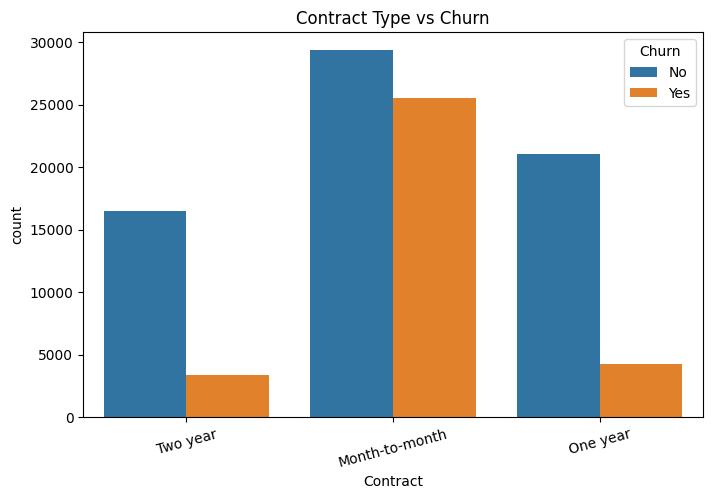

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title('Contract Type vs Churn')

plt.xticks(rotation=15)

plt.show()

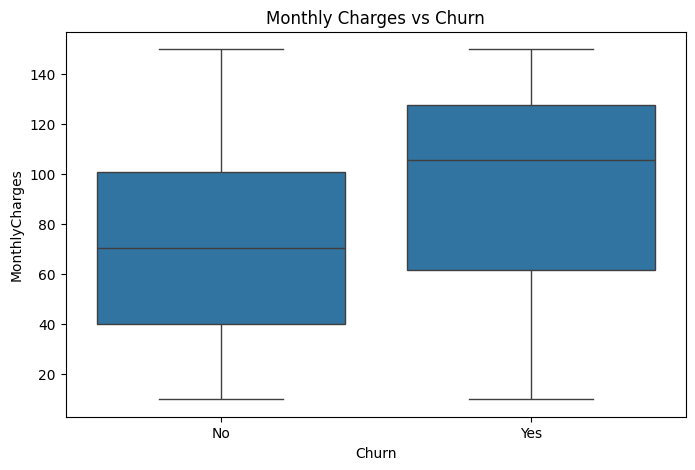

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges vs Churn')

plt.show()

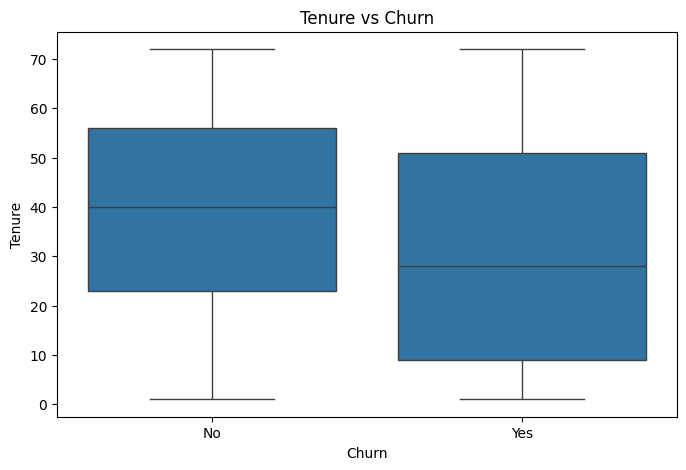

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='Tenure'
)

plt.title('Tenure vs Churn')

plt.show()

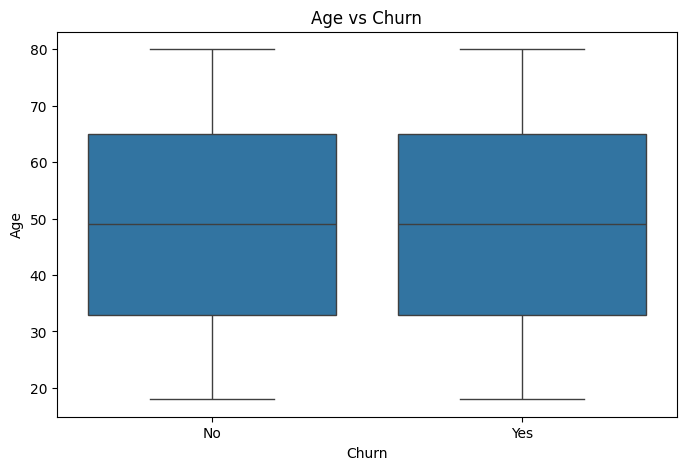

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='Age'
)

plt.title('Age vs Churn')

plt.show()

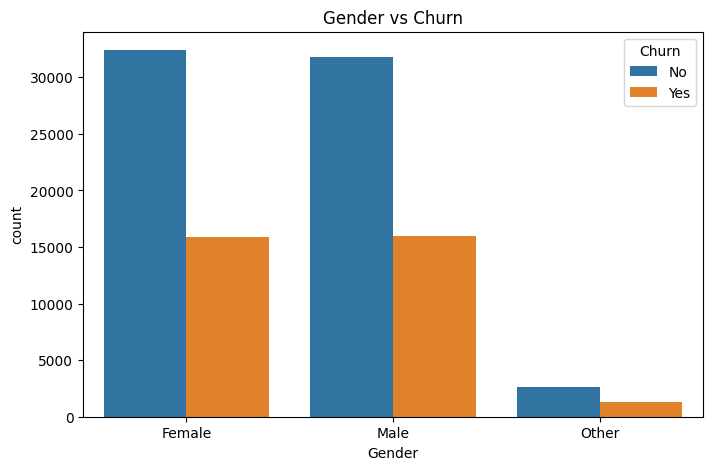

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Gender',
    hue='Churn'
)

plt.title('Gender vs Churn')

plt.show()

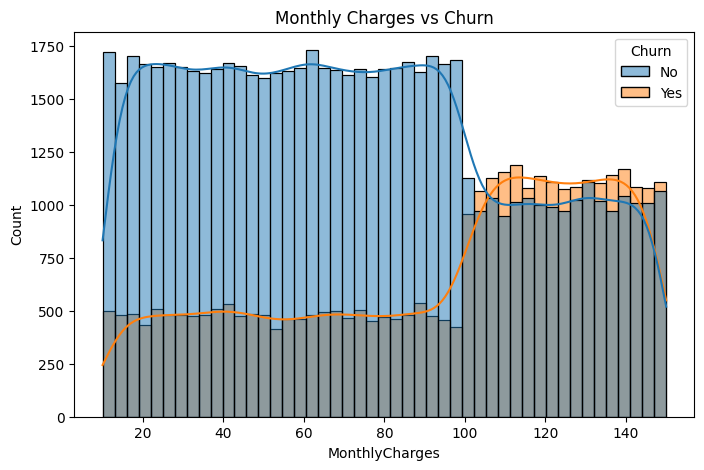

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    kde=True
)

plt.title('Monthly Charges vs Churn')

plt.show()

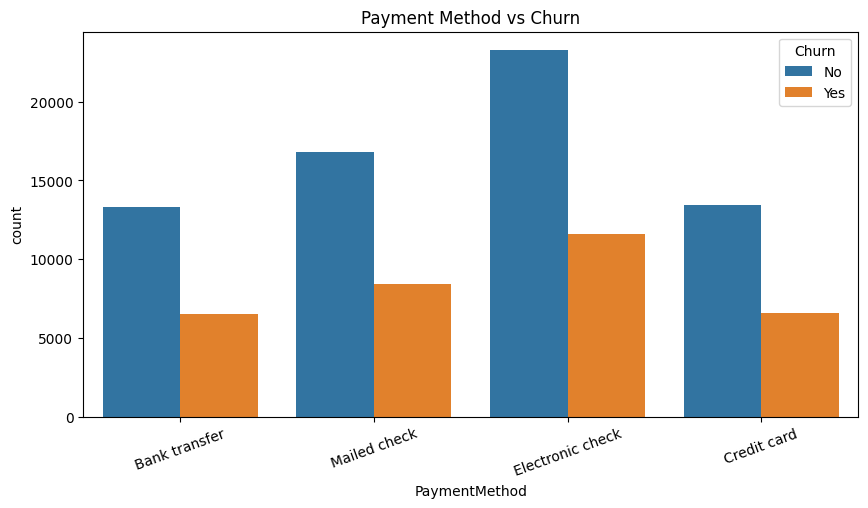

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn'
)

plt.title('Payment Method vs Churn')

plt.xticks(rotation=20)

plt.show()

In [24]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,53.442593,46.557407
One year,83.250861,16.749139
Two year,83.121469,16.878531


# Customer Churn Analysis

## Key Findings

### Contract Analysis
- Month-to-month customers have the highest churn rate (46.56%).
- One-year and two-year contracts show significantly lower churn rates (~17%).

### Tenure Analysis
- Customers with lower tenure are more likely to churn.
- Long-term customers demonstrate stronger retention.

### Payment Method Analysis
- Electronic Check customers show the highest churn volume.
- Credit Card and Bank Transfer customers appear more stable.

### Age Analysis
- Customer age does not appear to significantly influence churn behavior.

In [26]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer,66.995719,33.004281
Credit card,67.207468,32.792532
Electronic check,66.711567,33.288433
Mailed check,66.666667,33.333333


In [27]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     72.845838
Yes    94.355298
Name: MonthlyCharges, dtype: float64

In [28]:
df.groupby('Churn')['TotalCharges'].mean()

Churn
No     2886.019353
Yes    3007.069627
Name: TotalCharges, dtype: float64

In [29]:
from sklearn.preprocessing import LabelEncoder

df_corr = df.copy()

le = LabelEncoder()

for col in ['Gender','Contract','PaymentMethod','Churn']:
    df_corr[col] = le.fit_transform(df_corr[col])

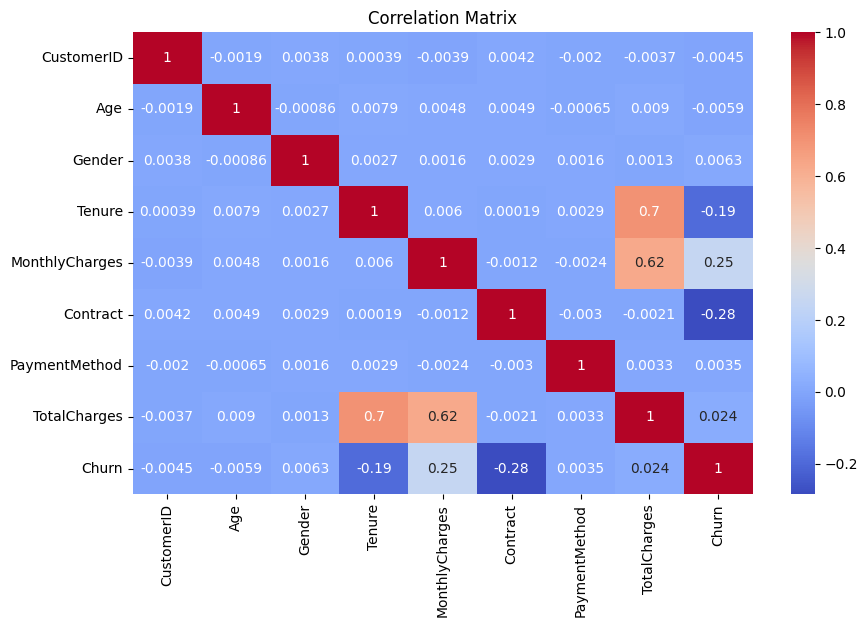

In [30]:
corr = df_corr.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

# Feature Engineering

In [31]:
df['LongTermCustomer'] = (
    df['Tenure'] >= 24
).astype(int)

df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn,LongTermCustomer
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No,1
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No,1
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No,0
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes,0
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No,1


In [32]:
df['AvgMonthlySpend'] = (
    df['TotalCharges'] /
    df['Tenure']
)

df['AvgMonthlySpend'] = (
    df['AvgMonthlySpend']
    .replace([np.inf, -np.inf], np.nan)
)

df['AvgMonthlySpend'] = (
    df['AvgMonthlySpend']
    .fillna(0)
)

In [33]:
df[['Tenure',
    'TotalCharges',
    'AvgMonthlySpend',
    'LongTermCustomer']].head()

,Tenure,TotalCharges,AvgMonthlySpend,LongTermCustomer
0,68,10052.03,147.823971,1
1,32,686.78,21.461875,1
2,10,537.88,53.788000,0
3,22,2390.04,108.638182,0
4,54,7081.28,131.134815,1


In [34]:
df.to_csv(
    '../data/churn_processed.csv',
    index=False
)

# Machine Learning - Churn Prediction

In [35]:
df_ml = df.copy()

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Gender','Contract','PaymentMethod','Churn']:
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn,LongTermCustomer,AvgMonthlySpend
0,1,56,0,68,147.58,2,0,10052.03,0,1,147.823971
1,2,69,1,32,22.54,0,3,686.78,0,1,21.461875
2,3,46,0,10,52.47,1,2,537.88,0,0,53.788000
3,4,32,1,22,109.67,0,3,2390.04,1,0,108.638182
4,5,60,0,54,130.98,0,1,7081.28,0,1,131.134815


In [37]:
X = df_ml.drop(
    ['CustomerID','Churn'],
    axis=1
)

y = df_ml['Churn']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
print(X_train.shape)
print(X_test.shape)

(80000, 9)
(20000, 9)


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [41]:
y_pred = rf.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.74075


In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.77      0.86      0.82     13294
           1       0.64      0.50      0.57      6706

    accuracy                           0.74     20000
   macro avg       0.71      0.68      0.69     20000
weighted avg       0.73      0.74      0.73     20000



In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[11431,  1863],
       [ 3322,  3384]])

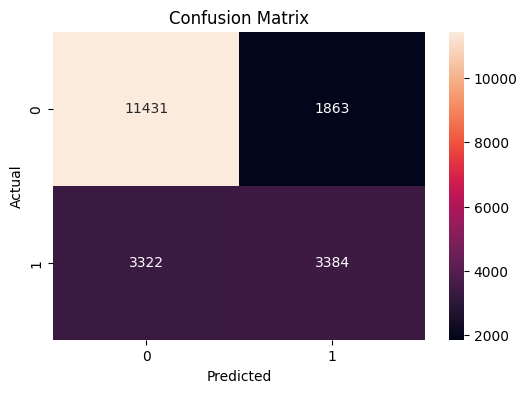

In [45]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [46]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
3,MonthlyCharges,0.215347
8,AvgMonthlySpend,0.180086
6,TotalCharges,0.164534
2,Tenure,0.152528
0,Age,0.118516
4,Contract,0.103080
5,PaymentMethod,0.036039
1,Gender,0.020344
7,LongTermCustomer,0.009527


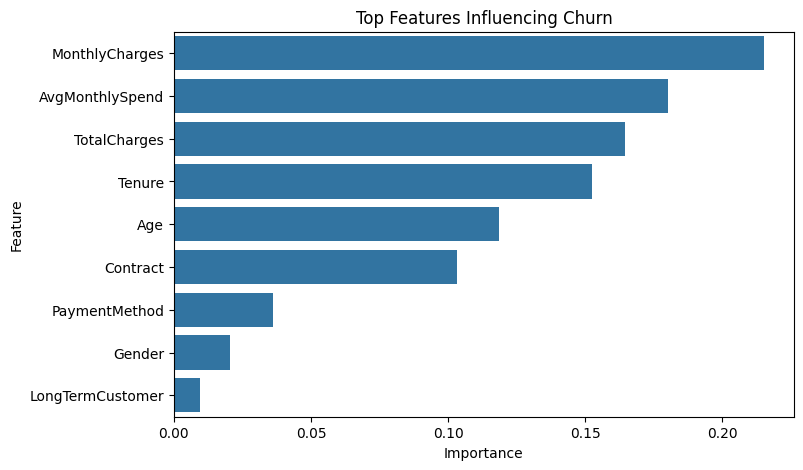

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top Features Influencing Churn')

plt.show()